# The necessary libraries

In [1]:
import cv2
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing
from skimage.filters import sobel
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy
import warnings
warnings.filterwarnings('ignore')

In [2]:
#input0 = r'C:\Users\Madhuri-Amit\Desktop\cvcp/'
input0 = r'C:\Users\akashshekhavat\CV lab\CV_CP\DataSet/'
temp = ['boatclub', 'classroom','corridor','playground']

# Data Preprocessing 

In [3]:
import cv2
import os
import numpy as np
import csv

input_folder = r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed/'   # Replace with your input folder path
output_folder = r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\SURF/'  # Replace with your output folder path
temp = ['boatclub', 'classroom', 'corridor', 'playground']

# Initialize SURF
surf = cv2.xfeatures2d.SURF_create()

# Loop through each subfolder in the input folder
for folder in temp:
    folder_path = os.path.join(input_folder, folder)
    output_folder_path = os.path.join(output_folder, folder)
    os.makedirs(output_folder_path, exist_ok=True)  # Create the output folder if it doesn't exist

    # Initialize lists to store keypoints and descriptors
    all_keypoints = []
    all_descriptors = np.empty((0, 128))

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        # Load the pre-processed image
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

        # Detect keypoints and compute descriptors using SURF
        keypoints, descriptors = surf.detectAndCompute(image, None)

        # Store the keypoints and descriptors
        all_keypoints.extend(keypoints)
        all_descriptors = np.vstack((all_descriptors, descriptors))

        # Draw keypoints on the image
        image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

        # Save the image with keypoints to the output folder
        output_file_path = os.path.join(output_folder_path, file_name)
        cv2.imwrite(output_file_path, image_with_keypoints)

    # Save the keypoints and descriptors to CSV files in the output folder
    keypoints_file_path = os.path.join(output_folder_path, folder + '_keypoints.csv')
    descriptors_file_path = os.path.join(output_folder_path, folder + '_descriptors.csv')

    with open(keypoints_file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows([k.pt for k in all_keypoints])

    with open(descriptors_file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(all_descriptors)

    print(f'Keypoints and descriptors saved for folder: {folder}')

print('SURF processing completed. Keypoints and descriptors saved to CSV files. Images with keypoints saved to output folder.')


error: OpenCV(4.7.0) D:\a\opencv-python\opencv-python\opencv_contrib\modules\xfeatures2d\src\surf.cpp:1028: error: (-213:The function/feature is not implemented) This algorithm is patented and is excluded in this configuration; Set OPENCV_ENABLE_NONFREE CMake option and rebuild the library in function 'cv::xfeatures2d::SURF::create'


In [4]:
import cv2
import os
import numpy as np
import csv

input_folder =r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed/'   # Replace with your input folder path
output_folder = r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\ORB/'  # Replace with your output folder path
temp = ['boatclub', 'classroom', 'corridor', 'playground']

# Initialize ORB
orb = cv2.ORB_create()

# Loop through each subfolder in the input folder
for folder in temp:
    folder_path = os.path.join(input_folder, folder)
    output_folder_path = os.path.join(output_folder, folder)
    os.makedirs(output_folder_path, exist_ok=True)  # Create the output folder if it doesn't exist

    # Initialize lists to store keypoints and descriptors
    all_keypoints = []
    all_descriptors = np.empty((0, 32))

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        # Load the pre-processed image
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

        # Detect keypoints and compute descriptors using ORB
        keypoints, descriptors = orb.detectAndCompute(image, None)

        # Store the keypoints and descriptors
        all_keypoints.extend(keypoints)
        all_descriptors = np.vstack((all_descriptors, descriptors))

        # Draw keypoints on the image
        image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

        # Save the image with keypoints to the output folder
        output_file_path = os.path.join(output_folder_path, file_name)
        cv2.imwrite(output_file_path, image_with_keypoints)

    # Save the keypoints and descriptors to CSV files in the output folder
    keypoints_file_path = os.path.join(output_folder_path, folder + '_keypoints.csv')
    descriptors_file_path = os.path.join(output_folder_path, folder + '_descriptors.csv')

    with open(keypoints_file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows([k.pt for k in all_keypoints])

    with open(descriptors_file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(all_descriptors)

    print(f'Keypoints and descriptors saved for folder: {folder}')

print('ORB processing completed. Keypoints and descriptors saved to CSV files. Images with keypoints saved to output folder.')


Keypoints and descriptors saved for folder: boatclub
Keypoints and descriptors saved for folder: classroom
Keypoints and descriptors saved for folder: corridor
Keypoints and descriptors saved for folder: playground
ORB processing completed. Keypoints and descriptors saved to CSV files. Images with keypoints saved to output folder.


In [5]:
import cv2
import os
import numpy as np
import csv

input_folder = r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed/'  # Replace with your input folder path
output_folder =  r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\BRISK/'  # Replace with your output folder path
temp = ['boatclub', 'classroom', 'corridor', 'playground']

# Initialize BRISK
brisk = cv2.BRISK_create()

# Loop through each subfolder in the input folder
for folder in temp:
    folder_path = os.path.join(input_folder, folder)
    output_folder_path = os.path.join(output_folder, folder)
    os.makedirs(output_folder_path, exist_ok=True)  # Create the output folder if it doesn't exist

    # Initialize lists to store keypoints and descriptors
    all_keypoints = []
    all_descriptors = np.empty((0, 64))

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        # Load the pre-processed image
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

        # Detect keypoints and compute descriptors using BRISK
        keypoints, descriptors = brisk.detectAndCompute(image, None)

        # Store the keypoints and descriptors
        all_keypoints.extend(keypoints)
        all_descriptors = np.vstack((all_descriptors, descriptors))

        # Draw keypoints on the image
        image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

        # Save the image with keypoints to the output folder
        output_file_path = os.path.join(output_folder_path, file_name)
        cv2.imwrite(output_file_path, image_with_keypoints)

    # Save the keypoints and descriptors to CSV files in the output folder
    keypoints_file_path = os.path.join(output_folder_path, folder + '_keypoints.csv')
    descriptors_file_path = os.path.join(output_folder_path, folder + '_descriptors.csv')

    with open(keypoints_file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows([k.pt for k in all_keypoints])

    with open(descriptors_file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(all_descriptors)

    print(f'Keypoints and descriptors saved for folder: {folder}')

print('BRISK processing completed. Keypoints and descriptors saved to CSV files. Images with keypoints saved to output folder.')


Keypoints and descriptors saved for folder: boatclub
Keypoints and descriptors saved for folder: classroom
Keypoints and descriptors saved for folder: corridor
Keypoints and descriptors saved for folder: playground
BRISK processing completed. Keypoints and descriptors saved to CSV files. Images with keypoints saved to output folder.


# FEature of BRISK 


In [30]:
import cv2
import os
import numpy as np
import csv

input_folder = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\BRISK"  # Replace with your input folder path
output_folder = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\New/"   # Replace with your output folder path
temp = ['boatclub', 'classroom', 'corridor', 'playground']

# Initialize AKAZE
akaze = cv2.AKAZE_create()

# Loop through each subfolder in the input folder
for folder in temp:
    folder_path = os.path.join(input_folder, folder)
    output_folder_path = os.path.join(output_folder, folder)
    os.makedirs(output_folder_path, exist_ok=True)  # Create the output folder if it doesn't exist

    # Initialize lists to store keypoints and descriptors
    all_keypoints = []
    all_descriptors = np.empty((0, 61))

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        # Load the pre-processed image
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

        # Detect keypoints and compute descriptors using AKAZE
        keypoints, descriptors = akaze.detectAndCompute(image, None)

        # Store the keypoints and descriptors
        all_keypoints.extend(keypoints)
        all_descriptors = np.vstack((all_descriptors, descriptors))

        # Draw keypoints on the image
        image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

        # Save the image with keypoints to the output folder
        output_file_path = os.path.join(output_folder_path, file_name)
        cv2.imwrite(output_file_path, image_with_keypoints)

    # Save the keypoints and descriptors to CSV files in the output folder
    keypoints_file_path = os.path.join(output_folder_path, folder + '_keypoints.csv')
    descriptors_file_path = os.path.join(output_folder_path, folder + '_descriptors.csv')

    with open(keypoints_file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows([k.pt for k in all_keypoints])

    with open(descriptors_file_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(all_descriptors)

    print(f'Keypoints and descriptors saved for folder: {folder}')

print('AKAZE processing completed. Keypoints and descriptors saved to CSV files. Images with keypoints saved to output folder.')


error: OpenCV(4.7.0) D:\a\opencv-python\opencv-python\opencv\modules\features2d\src\akaze.cpp:172: error: (-215:Assertion failed) ! image.empty() in function 'cv::AKAZE_Impl::detectAndCompute'


In [31]:
import cv2
import os
import numpy as np
import csv

input_folder = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\Combined"  # Replace with your input folder path
output_folder = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\New/"   # Replace with your output folder path
temp = ['boatclub', 'classroom', 'corridor', 'playground']

# Initialize SIFT and BRISK
sift = cv2.SIFT_create()
brisk = cv2.BRISK_create()

# Loop through each subfolder in the input folder
for folder in temp:
    folder_path = os.path.join(input_folder, folder)
    output_folder_path = os.path.join(output_folder, folder)
    os.makedirs(output_folder_path, exist_ok=True)  # Create the output folder if it doesn't exist

    # Initialize lists to store keypoints and descriptors
    all_sift_keypoints = []
    all_sift_descriptors = np.empty((0, 128))
    all_brisk_keypoints = []
    all_brisk_descriptors = np.empty((0, 61))

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        # Load the pre-processed image
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

        # Detect keypoints and compute descriptors using SIFT
        sift_keypoints, sift_descriptors = sift.detectAndCompute(image, None)

        # Store the keypoints and descriptors
        all_sift_keypoints.extend(sift_keypoints)
        all_sift_descriptors = np.vstack((all_sift_descriptors, sift_descriptors))

        # Detect keypoints and compute descriptors using BRISK
        brisk_keypoints, brisk_descriptors = brisk.detectAndCompute(image, None)

        # Store the keypoints and descriptors
        all_brisk_keypoints.extend(brisk_keypoints)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\akashshekhavat\\CV lab\\CV_CP\\CP_Project\\Feature_Ext\\Combined\\boatclub'

Number of SIFT features:  219
Number of BRISK features:  188
Number of AKAZE features:  104
Number of KAZE features:  238
Number of MSER features:  170
Number of AGAST features:  696


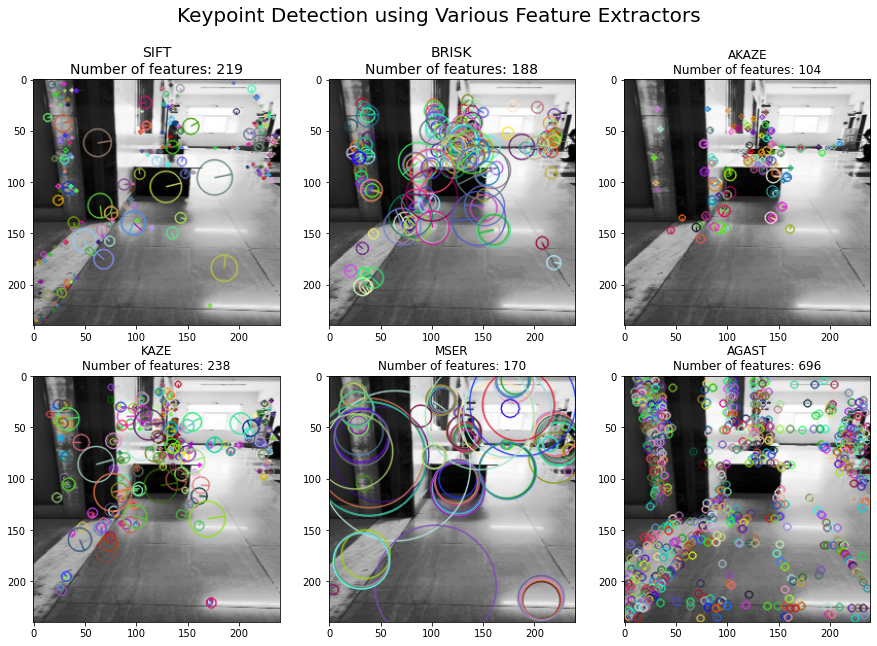

In [2]:
import cv2
import os
import numpy as np
import csv

import matplotlib.pyplot as plt

input_image = r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed\corridor\WhatsApp Image 2023-04-19 at 20.57.10.jpeg'  # Replace with your input image path

# Initialize feature extractors
sift = cv2.xfeatures2d.SIFT_create()
brisk = cv2.BRISK_create()
akaze = cv2.AKAZE_create()
kaze = cv2.KAZE_create()
mser = cv2.MSER_create()
agast = cv2.AgastFeatureDetector_create()

# Load the input image
image = cv2.imread(input_image, cv2.IMREAD_GRAYSCALE)

# Detect keypoints and compute descriptors using each feature extractor
keypoints_sift, descriptors_sift = sift.detectAndCompute(image, None)
keypoints_brisk, descriptors_brisk = brisk.detectAndCompute(image, None)
keypoints_akaze, descriptors_akaze = akaze.detectAndCompute(image, None)
keypoints_kaze, descriptors_kaze = kaze.detectAndCompute(image, None)
keypoints_mser = mser.detect(image, None)
keypoints_agast = agast.detect(image, None)

# Draw keypoints on the input image for each feature extractor
image_sift = cv2.drawKeypoints(image, keypoints_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_brisk = cv2.drawKeypoints(image, keypoints_brisk, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_akaze = cv2.drawKeypoints(image, keypoints_akaze, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_kaze = cv2.drawKeypoints(image, keypoints_kaze, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_mser = cv2.drawKeypoints(image, keypoints_mser, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_agast = cv2.drawKeypoints(image, keypoints_agast, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

print("Number of SIFT features: ", len(keypoints_sift))
print("Number of BRISK features: ", len(keypoints_brisk))
print("Number of AKAZE features: ", len(keypoints_akaze))
print("Number of KAZE features: ", len(keypoints_kaze))
print("Number of MSER features: ", len(keypoints_mser))
print("Number of AGAST features: ", len(keypoints_agast))

# Display the input image with keypoints for each feature extractor in a single figure
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Keypoint Detection using Various Feature Extractors', fontsize=20)

axs[0, 0].imshow(image_sift)
axs[0, 0].set_title('SIFT\nNumber of features: {}'.format(len(keypoints_sift)), fontsize=14)
axs[0, 1].imshow(image_brisk)
axs[0, 1].set_title('BRISK\nNumber of features: {}'.format(len(keypoints_brisk)), fontsize=14)
axs[0, 2].imshow(image_akaze)
axs[0, 2].set_title('AKAZE\nNumber of features: {}'.format(len(keypoints_akaze)))
axs[1, 0].imshow(image_kaze)
axs[1, 0].set_title('KAZE')
axs[1, 0].imshow(image_kaze)
axs[1, 0].set_title('KAZE\nNumber of features: {}'.format(len(keypoints_kaze)))
axs[1, 1].imshow(image_mser)
axs[1, 1].set_title('MSER')
axs[1, 1].imshow(image_mser)
axs[1, 1].set_title('MSER\nNumber of features: {}'.format(len(keypoints_mser)))
axs[1, 2].imshow(image_agast)
axs[1, 2].set_title('AGAST')
axs[1, 2].imshow(image_agast)
axs[1, 2].set_title('AGAST\nNumber of features: {}'.format(len(keypoints_agast)))





plt.show()
cv2.waitKey(0)
cv2.destroyAllWindows()


Number of SIFT features:  219
Number of BRISK features:  188
Number of AKAZE features:  104
Number of KAZE features:  238
Number of MSER features:  170
Number of AGAST features:  696


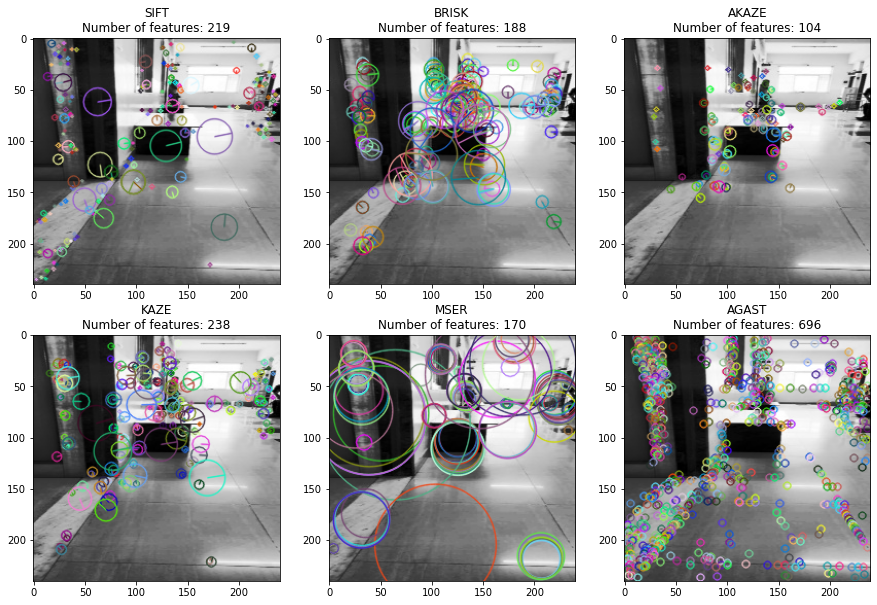

In [1]:
import cv2
import os
import numpy as np
import csv

import matplotlib.pyplot as plt

input_image = r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed\corridor\WhatsApp Image 2023-04-19 at 20.57.10.jpeg'  # Replace with your input image path

# Initialize feature extractors
sift = cv2.xfeatures2d.SIFT_create()
brisk = cv2.BRISK_create()
akaze = cv2.AKAZE_create()
kaze = cv2.KAZE_create()
mser = cv2.MSER_create()
agast = cv2.AgastFeatureDetector_create()



# Load the input image
image = cv2.imread(input_image, cv2.IMREAD_GRAYSCALE)

# Detect keypoints and compute descriptors using each feature extractor
keypoints_sift, descriptors_sift = sift.detectAndCompute(image, None)
keypoints_brisk, descriptors_brisk = brisk.detectAndCompute(image, None)
keypoints_akaze, descriptors_akaze = akaze.detectAndCompute(image, None)
keypoints_kaze, descriptors_kaze = kaze.detectAndCompute(image, None)
keypoints_mser = mser.detect(image, None)
keypoints_agast = agast.detect(image, None)


# Draw keypoints on the input image for each feature extractor
image_sift = cv2.drawKeypoints(image, keypoints_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_brisk = cv2.drawKeypoints(image, keypoints_brisk, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_akaze = cv2.drawKeypoints(image, keypoints_akaze, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_kaze = cv2.drawKeypoints(image, keypoints_kaze, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_mser = cv2.drawKeypoints(image, keypoints_mser, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_agast = cv2.drawKeypoints(image, keypoints_agast, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

print("Number of SIFT features: ", len(keypoints_sift))
print("Number of BRISK features: ", len(keypoints_brisk))
print("Number of AKAZE features: ", len(keypoints_akaze))
print("Number of KAZE features: ", len(keypoints_kaze))
print("Number of MSER features: ", len(keypoints_mser))
print("Number of AGAST features: ", len(keypoints_agast))





# Display the input image with keypoints for each feature extractor in a single figure
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].imshow(image_sift)
axs[0, 0].set_title('SIFT')
axs[0, 0].imshow(image_sift)
axs[0, 0].set_title('SIFT\nNumber of features: {}'.format(len(keypoints_sift)))
axs[0, 1].imshow(image_brisk)
axs[0, 1].set_title('BRISK')
axs[0, 1].imshow(image_brisk)
axs[0, 1].set_title('BRISK\nNumber of features: {}'.format(len(keypoints_brisk)))
axs[0, 2].imshow(image_akaze)
axs[0, 2].set_title('AKAZE')
axs[0, 2].imshow(image_akaze)
axs[0, 2].set_title('AKAZE\nNumber of features: {}'.format(len(keypoints_akaze)))
axs[1, 0].imshow(image_kaze)
axs[1, 0].set_title('KAZE')
axs[1, 0].imshow(image_kaze)
axs[1, 0].set_title('KAZE\nNumber of features: {}'.format(len(keypoints_kaze)))
axs[1, 1].imshow(image_mser)
axs[1, 1].set_title('MSER')
axs[1, 1].imshow(image_mser)
axs[1, 1].set_title('MSER\nNumber of features: {}'.format(len(keypoints_mser)))
axs[1, 2].imshow(image_agast)
axs[1, 2].set_title('AGAST')
axs[1, 2].imshow(image_agast)
axs[1, 2].set_title('AGAST\nNumber of features: {}'.format(len(keypoints_agast)))





plt.show()
cv2.waitKey(0)
cv2.destroyAllWindows()


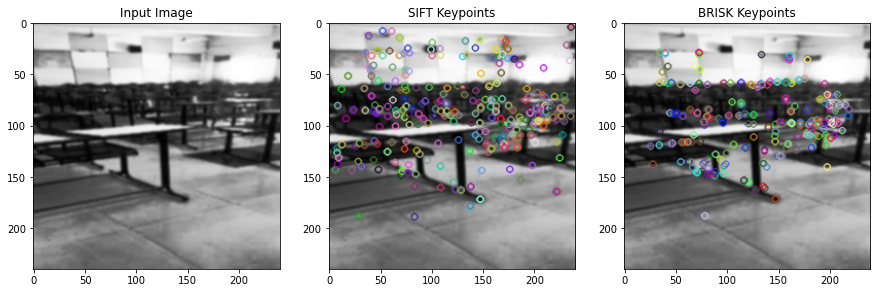

In [21]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread(r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed\classroom\7.jpg')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Initialize feature detectors and descriptors
sift = cv2.xfeatures2d.SIFT_create()
brisk = cv2.BRISK_create()

# Detect keypoints and compute descriptors
kp_sift, desc_sift = sift.detectAndCompute(gray, None)
kp_brisk, desc_brisk = brisk.detectAndCompute(gray, None)

# Draw keypoints on the input image for each feature extractor
img_sift = cv2.drawKeypoints(gray, kp_sift, None)
img_brisk = cv2.drawKeypoints(gray, kp_brisk, None)

# Plot the input image and the output images
fig, axs = plt.subplots(1, 3, figsize=(15,15))
axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].set_title('Input Image')
axs[1].imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
axs[1].set_title('SIFT Keypoints')
axs[2].imshow(cv2.cvtColor(img_brisk, cv2.COLOR_BGR2RGB))
axs[2].set_title('BRISK Keypoints')
plt.show()


In [26]:
import cv2
import numpy as np

img = cv2.imread(r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed\classroom\7.jpg")
sift = cv2.SIFT_create()
brisk = cv2.BRISK_create(descLength=128, radiusList=[3, 6, 9, 12],  )

kp_sift, desc_sift = sift.detectAndCompute(img, None)
kp_brisk, desc_brisk = brisk.detectAndCompute(img, None)

# Concatenate the descriptors
desc_sift_brisk = np.concatenate((desc_sift, desc_brisk), axis=1)

# Draw keypoints on the input image for the concatenated descriptor
img_sift_brisk = cv2.drawKeypoints(img, kp_sift + kp_brisk, None)

# Display the output image
cv2.imshow('SIFT+BRISK Keypoints', img_sift_brisk)
cv2.waitKey(0)
cv2.destroyAllWindows()


error: OpenCV(4.7.0) :-1: error: (-5:Bad argument) in function 'BRISK_create'
> Overload resolution failed:
>  - 'descLength' is an invalid keyword argument for BRISK_create()
>  - BRISK_create() missing required argument 'numberList' (pos 2)
>  - BRISK_create() missing required argument 'thresh' (pos 1)


In [27]:
import cv2
import numpy as np

img = cv2.imread(r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed\classroom\7.jpg")

# Create SIFT and AKAZE feature detectors
sift = cv2.SIFT_create()
akaze = cv2.AKAZE_create()

# Detect keypoints and compute descriptors using SIFT
kp_sift, desc_sift = sift.detectAndCompute(img, None)

# Detect keypoints and compute descriptors using AKAZE
kp_akaze, desc_akaze = akaze.detectAndCompute(img, None)

# Concatenate the descriptors
desc_sift_akaze = np.concatenate((desc_sift, desc_akaze), axis=1)

# Draw keypoints on the input image for the concatenated descriptor
img_sift_akaze = cv2.drawKeypoints(img, kp_sift + kp_akaze, None)

# Display the output image
cv2.imshow('SIFT+AKAZE Keypoints', img_sift_akaze)
cv2.waitKey(0)
cv2.destroyAllWindows()


ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 296 and the array at index 1 has size 193

# SIFT+KAZE+BRISK

In [2]:
import cv2

# Load the image
img = cv2.imread(r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\BRISK\CSV_BRISK/')

# Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Initialize the feature detectors
sift = cv2.SIFT_create()
kaze = cv2.KAZE_create()
brisk = cv2.BRISK_create()

# Detect keypoints and compute descriptors using each detector
kp_sift, des_sift = sift.detectAndCompute(gray, None)
kp_kaze, des_kaze = kaze.detectAndCompute(gray, None)
kp_brisk, des_brisk = brisk.detectAndCompute(gray, None)

# Concatenate the descriptors
descriptors = cv2.vconcat([des_sift, des_kaze, des_brisk])

# Draw the keypoints on the image
img_keypoints = cv2.drawKeypoints(img, kp_sift, None)
img_keypoints = cv2.drawKeypoints(img_keypoints, kp_kaze, None)
img_keypoints = cv2.drawKeypoints(img_keypoints, kp_brisk, None)

# Display the image with keypoints
cv2.imshow('Image with Keypoints', img_keypoints)
cv2.waitKey(0)
cv2.destroyAllWindows()


error: OpenCV(4.7.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:182: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


# Saving All decriptor BRISK csv file

In [9]:
import os
import pandas as pd

# Set the directory path
dir_path = r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\BRISK\CSV_BRISK'

# Initialize an empty DataFrame to store the descriptors
all_descriptors = pd.DataFrame()

# Loop through each file in the directory
for filename in os.listdir(dir_path):
    if filename.endswith('.csv'):
        # Load the descriptor CSV file into a DataFrame
        descriptor_df = pd.read_csv(os.path.join(dir_path, filename))
        # Concatenate the descriptor DataFrame with the all_descriptors DataFrame
        all_descriptors = pd.concat([all_descriptors, descriptor_df])

# Save the concatenated DataFrame to a CSV file in the output folder
output_dir = r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\BRISK\OUTPUT'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
output_file = os.path.join(output_dir, 'all_descriptors.csv')
all_descriptors.to_csv(output_file, index=False)


In [10]:
import os
import pandas as pd

# Set the directory path
dir_path = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\AKAZE\CSV_AKAZE"

# Initialize an empty DataFrame to store the descriptors
all_descriptors = pd.DataFrame()

# Loop through each file in the directory
for filename in os.listdir(dir_path):
    if filename.endswith('.csv'):
        # Load the descriptor CSV file into a DataFrame
        descriptor_df = pd.read_csv(os.path.join(dir_path, filename))
        # Concatenate the descriptor DataFrame with the all_descriptors DataFrame
        all_descriptors = pd.concat([all_descriptors, descriptor_df])

# Save the concatenated DataFrame to a CSV file in the output folder
output_dir = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\AKAZE\OUTPUT"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
output_file = os.path.join(output_dir, 'all_descriptors.csv')
all_descriptors.to_csv(output_file, index=False)


In [11]:
import os
import pandas as pd

# Set the directory path
dir_path = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\ORB\CSV_ORB"

# Initialize an empty DataFrame to store the descriptors
all_descriptors = pd.DataFrame()

# Loop through each file in the directory
for filename in os.listdir(dir_path):
    if filename.endswith('.csv'):
        # Load the descriptor CSV file into a DataFrame
        descriptor_df = pd.read_csv(os.path.join(dir_path, filename))
        # Concatenate the descriptor DataFrame with the all_descriptors DataFrame
        all_descriptors = pd.concat([all_descriptors, descriptor_df])

# Save the concatenated DataFrame to a CSV file in the output folder
output_dir = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\ORB\OUTPUT"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
output_file = os.path.join(output_dir, 'all_descriptors.csv')
all_descriptors.to_csv(output_file, index=False)


In [12]:
import cv2
import numpy as np
import os
import csv

# Function to extract KAZE features from an image
def extract_kaze_features(image):
    kaze = cv2.KAZE_create()
    _, descriptors = kaze.detectAndCompute(image, None)
    return descriptors

# Path to the folder containing subfolders of images
path =r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed"

# List of subfolders in the folder
subfolders = sorted(os.listdir(path))

# Open a CSV file to save the features
csv_file = "kaze_features.csv"
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Loop through the subfolders and extract features from each image
    for folder in subfolders:
        folder_path = os.path.join(path, folder)
        images = sorted(os.listdir(folder_path))
        
        for img_name in images:
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            # Extract KAZE features from the image
            features = extract_kaze_features(img)
            if features is not None:
                # Add the features to the CSV file
                writer.writerow(features.flatten())

KeyboardInterrupt: 

In [13]:
import cv2
import numpy as np
import os
import csv

# Function to extract BRISK features from an image
def extract_brisk_features(image):
    brisk = cv2.BRISK_create()
    _, descriptors = brisk.detectAndCompute(image, None)
    return descriptors

# Path to the folder containing subfolders of images
path =r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed"

# List of subfolders in the folder
subfolders = sorted(os.listdir(path))

# Open a CSV file to save the features
csv_file = "brisk_features.csv"
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Loop through the subfolders and extract features from each image
    for folder in subfolders:
        folder_path = os.path.join(path, folder)
        images = sorted(os.listdir(folder_path))
        
        for img_name in images:
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            # Extract BRISK features from the image
            features = extract_brisk_features(img)
            if features is not None:
                # Add the features to the CSV file
                writer.writerow(features.flatten())


In [14]:
import cv2
import numpy as np
import os
import csv

# Function to extract AKAZE features from an image
def extract_akaze_features(image):
    akaze = cv2.AKAZE_create()
    _, descriptors = akaze.detectAndCompute(image, None)
    return descriptors

# Path to the folder containing subfolders of images
path =r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed"

# List of subfolders in the folder
subfolders = sorted(os.listdir(path))

# Open a CSV file to save the features
csv_file = "akaze_features.csv"
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Loop through the subfolders and extract features from each image
    for folder in subfolders:
        folder_path = os.path.join(path, folder)
        images = sorted(os.listdir(folder_path))
        
        for img_name in images:
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            # Extract AKAZE features from the image
            features = extract_akaze_features(img)
            if features is not None:
                # Add the features to the CSV file
                writer.writerow(features.flatten())


In [15]:
import cv2
import numpy as np
import os
import csv

# Function to extract ORB features from an image
def extract_orb_features(image):
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(image, None)
    return descriptors

# Path to the folder containing subfolders of images
path = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed"

# List of subfolders in the folder
subfolders = sorted(os.listdir(path))

# Open a CSV file to save the features
csv_file = "orb_features.csv"
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Loop through the subfolders and extract features from each image
    for folder in subfolders:
        folder_path = os.path.join(path, folder)
        images = sorted(os.listdir(folder_path))
        
        for img_name in images:
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            # Extract ORB features from the image
            features = extract_orb_features(img)
            if features is not None:
                # Add the features to the CSV file
                writer.writerow(features.flatten())


In [25]:
import pandas as pd

# read the first CSV file
df1 = pd.read_csv('akaze_brisk_features1.csv')

# read the second CSV file
df2 = pd.read_csv('akaze_brisk_features2.csv')

# concatenate both dataframes
df = pd.concat([df1, df2], ignore_index=True)

# save the combined dataframe to a new CSV file
df.to_csv('akaze_brisk_combined.csv', index=False)


FileNotFoundError: [Errno 2] No such file or directory: 'akaze_brisk_features1.csv'

In [33]:
import cv2
import os
import numpy as np
import pandas as pd

# Define the path to the folder containing subfolders of images
folder_path = r"C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\Feature_Ext\New"

# Create empty lists to store the feature vectors and image names
features = []
names = []

# Loop through each subfolder in the folder
for subfolder in os.listdir(folder_path):
    subfolder_path = os.path.join(folder_path, subfolder)
    
    # Loop through each file in the subfolder
    for file in os.listdir(subfolder_path):
        file_path = os.path.join(subfolder_path, file)
        
        # Read the image
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        
        # Flatten the image to create a feature vector
        feature_vector = img.flatten()
        
        # Add the feature vector to the list of features
        features.append(feature_vector)
        
        # Add the image name to the list of names
        names.append(file)

# Convert the feature vectors and image names to NumPy arrays
features = np.array(features)
names = np.array(names)

# Create a Pandas DataFrame to store the feature vectors
df = pd.DataFrame(features)

# Add a column to the DataFrame with the image names
df['filename'] = names

# Save the DataFrame to a CSV file
df.to_csv("features.csv", index=False)

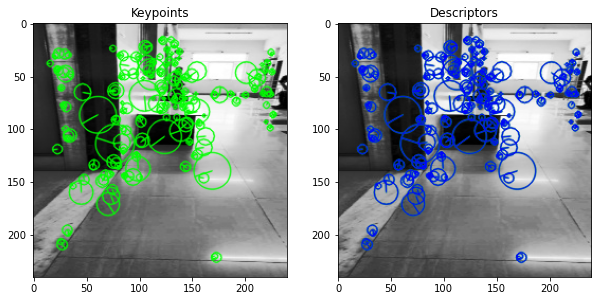

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the input image
input_image = cv2.imread(r'C:\Users\akashshekhavat\CV lab\CV_CP\CP_Project\preprocessed\corridor\WhatsApp Image 2023-04-19 at 20.57.10.jpeg', cv2.IMREAD_GRAYSCALE)

# Initialize the KAZE detector and BRISK descriptor extractor
kaze = cv2.KAZE_create()
brisk = cv2.BRISK_create()

# Detect keypoints using KAZE
keypoints = kaze.detect(input_image, None)

# Compute descriptors using BRISK
keypoints, descriptors = brisk.compute(input_image, keypoints)

# Draw keypoints and descriptors on the input image
image_with_keypoints = cv2.drawKeypoints(input_image, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_with_descriptors = cv2.drawKeypoints(image_with_keypoints, keypoints, None, color=(0, 0, 255), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the input image with keypoints and descriptors overlaid
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image_with_keypoints)
axs[0].set_title('Keypoints')
axs[1].imshow(image_with_descriptors)
axs[1].set_title('Descriptors')
plt.show()
